In [1]:
using CairoMakie

include("./module_metropolis.jl")

# config plot theme.
set_theme!(
    font = "Computer Modern",
    pt_per_unit = 1.0,
    Axis = (
        titlesize = 25,
        labelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 20,
        yticklabelsize = 20,
        xgridvisible = true,
        ygridvisible = true,
        xgridstyle = :dash,
        ygridstyle = :dash,
        xgridcolor = (:gray, 0.2),
        ygridcolor = (:gray, 0.2)
    ))

## Dynamics of magnetization and energy

Running 500 sweeps...


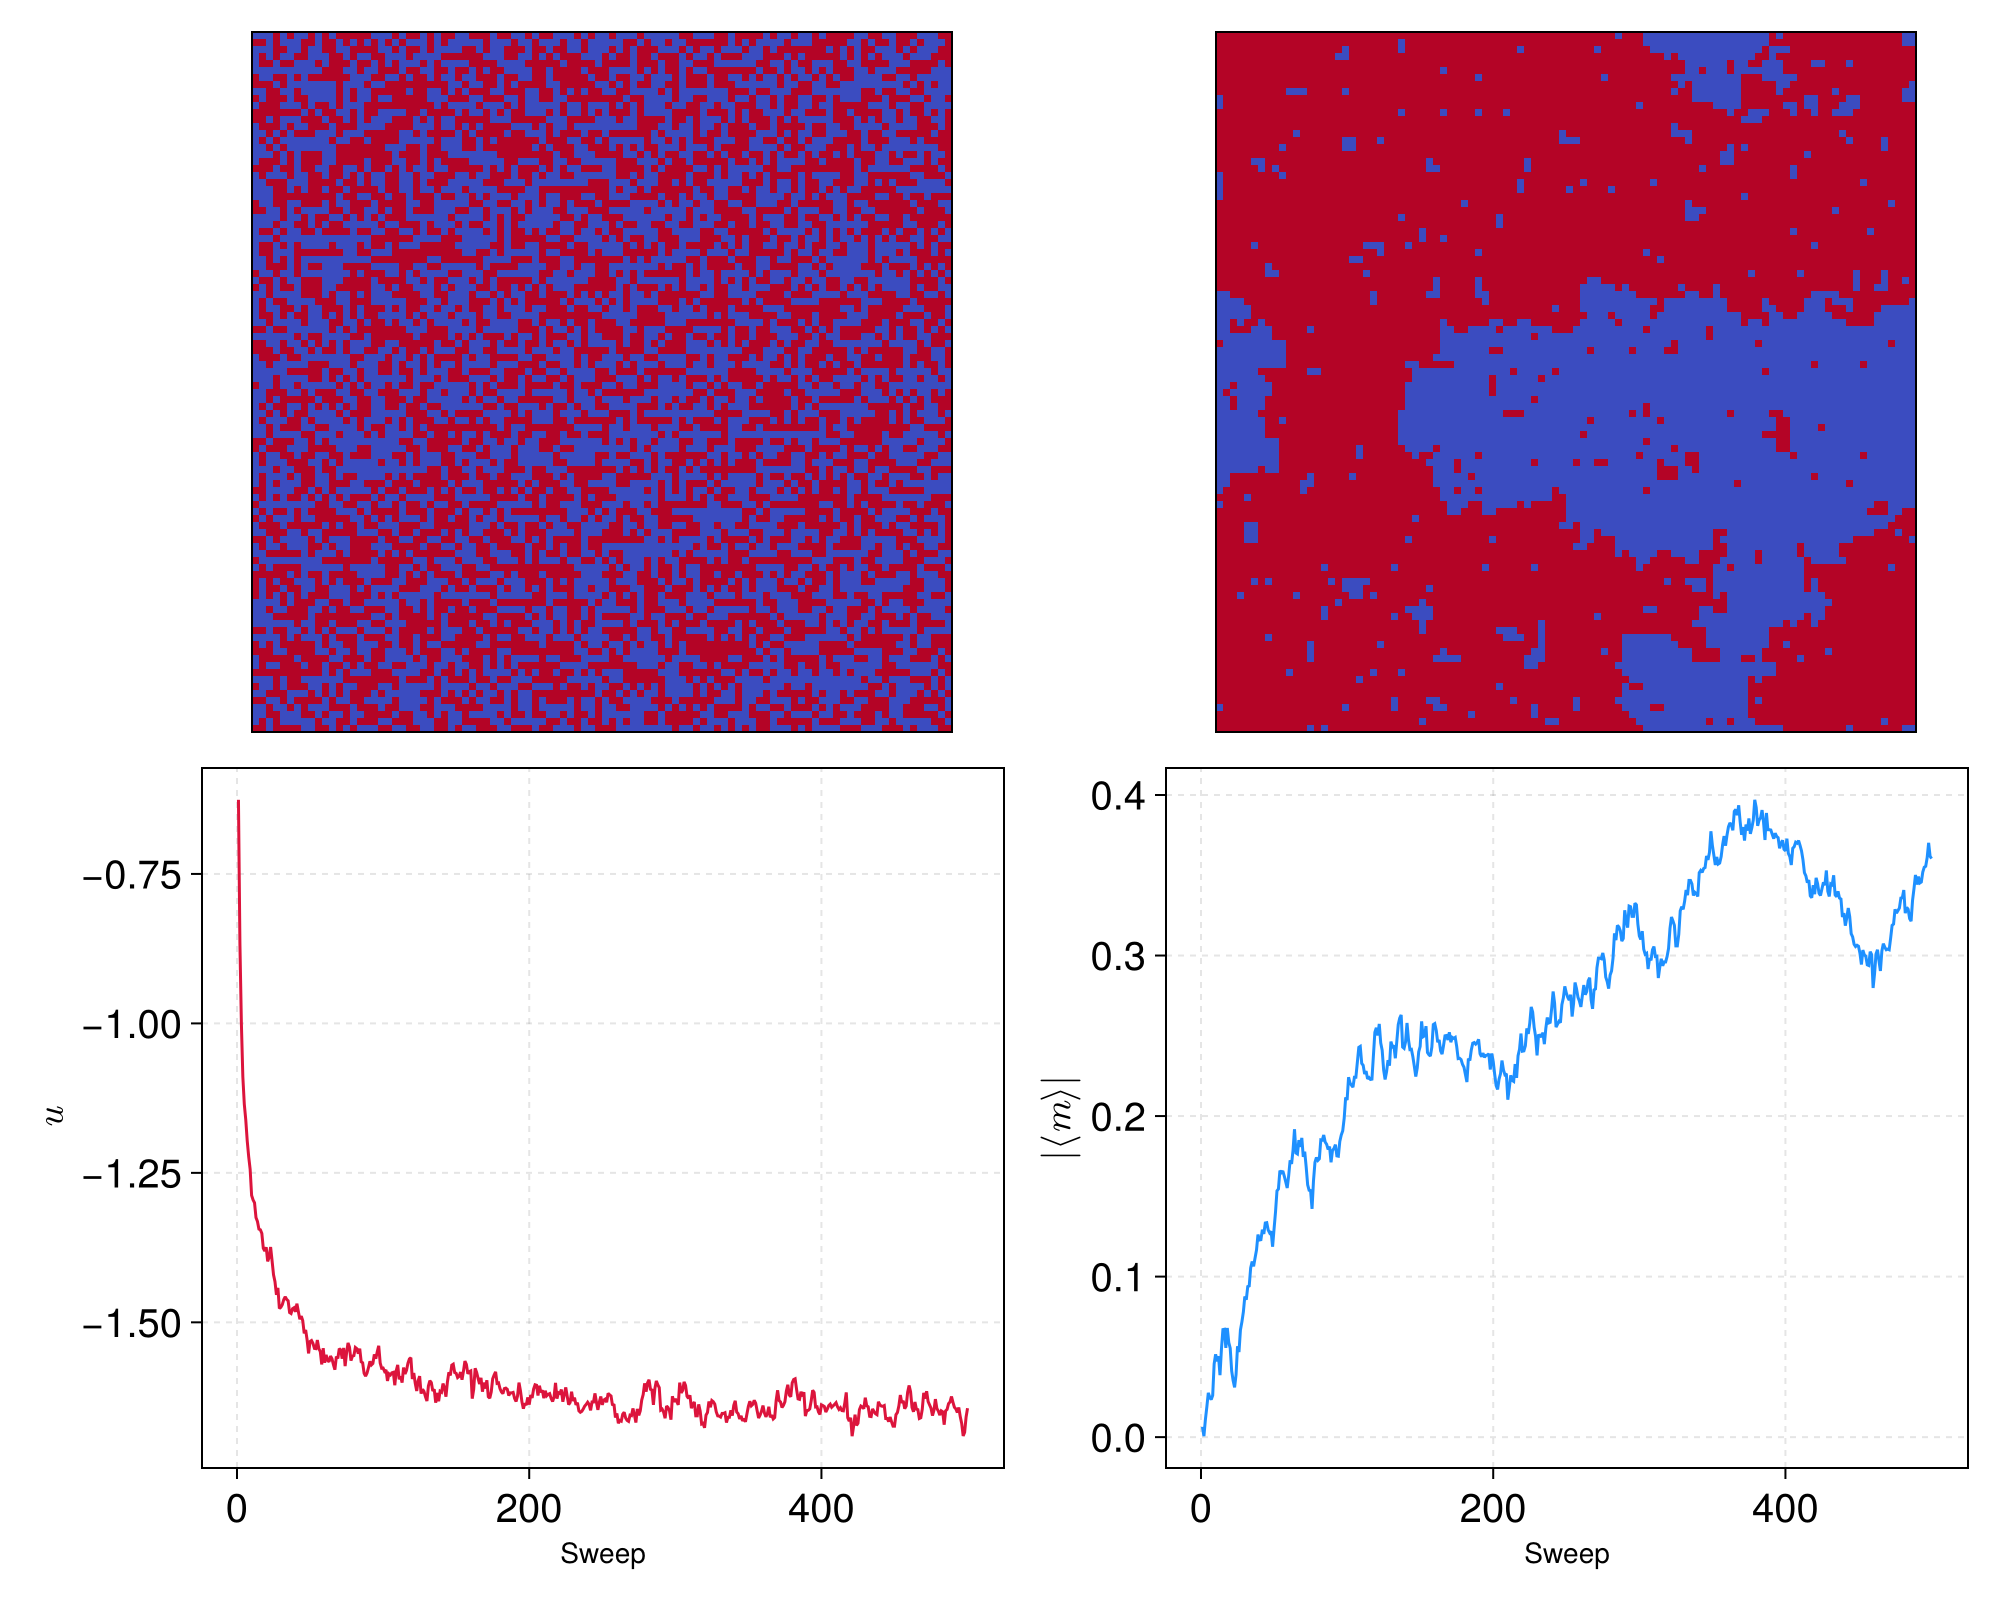

In [2]:
let
    # Parameters
    L = 100
    nsweeps = 500
    T = 2.0
    beta = 1/T
    J = 1.0
    N = L^2

    # 1. Initialize
    lattice = initial_lattice_state(L, 0)

    initial_lattice_snapshot = copy(lattice)

    # Calculate starting metrics
    current_E = energy(lattice, J)
    current_M = sum(lattice)

    # Arrays to log data per sweep
    energy_history = Vector{Float64}(undef, nsweeps)
    mag_history = Vector{Float64}(undef, nsweeps)

    # 2. Evolution Loop
    println("Running $nsweeps sweeps...")
    for sweep in 1:nsweeps
        current_E, current_M = metropolis_sweep!(lattice, current_E, current_M, beta, J)
        # Track quantities normalized *per spin*
        energy_history[sweep] = current_E / N
        mag_history[sweep] = current_M / N
    end

    # 3. Plotting with CairoMakie
    fig = Figure(size = (1000, 800))
    # Top Left: Initial Grid
    ax1 = Axis(fig[1, 1], aspect = DataAspect())
    hidedecorations!(ax1)
    heatmap!(ax1, initial_lattice_snapshot, colormap = :coolwarm)

    # Top Right: Final Grid
    ax2 = Axis(fig[1, 2], aspect = DataAspect())
    hidedecorations!(ax2)
    heatmap!(ax2, lattice, colormap = :coolwarm)

    # Bottom Left: Energy history per spin
    ax3 = Axis(fig[2, 1], xlabel = "Sweep", ylabel = L"$u$")
    lines!(ax3, 1:nsweeps, energy_history, color = :crimson)
    ax4 = Axis(fig[2, 2], xlabel = "Sweep",  ylabel = L"$|\langle m \rangle|$")
    lines!(ax4, 1:nsweeps, abs.(mag_history), color = :dodgerblue)
    fig 
end

Generate a gif.

In [3]:
let
    L = 100
    nsweeps = 400
    frame_interval = 4
    T = 1.5                   
    beta = 1/T
    J = 1.0
    N = L^2

    lattice = initial_lattice_state(L, 0)
    current_E = energy(lattice, J)
    current_M = sum(lattice)

    lattice_observable = Observable(copy(lattice))

    fig = Figure(size = (500, 500))
    ax = Axis(fig[1, 1], title = "T = $T", aspect = DataAspect())
    hidedecorations!(ax) 
    
    heatmap!(ax, lattice_observable, colormap = :coolwarm, colorrange = (-1, 1))
    inline_anim = record(fig, "ising_evolution.gif", 1:nsweeps; framerate = 24) do sweep
        current_E, current_M = metropolis_sweep!(lattice, current_E, current_M, beta, J)
        if sweep % frame_interval == 0
            lattice_observable[] = copy(lattice)
        end
    end
    inline_anim
end

"ising_evolution.gif"

# Phase transition

\begin{align*}
    c_{V} (T) = \frac{1}{N T^2} \left( \braket{E(T)^2} - \braket{E(T)}^2\right) \\ 
    \Chi = \frac{1}{N K_B T} \left( \braket{m^2} - |\braket{m}|^2\right)
\end{align*}

In [5]:
function phase_diagram(L, T_range; thermal_sweeps = 200, sampling_sweeps = 500)    
    lattice = initial_lattice_state(L, 1)
    E_out = Float64[]
    M_out = Float64[]
    Cv_out = Float64[]
    Chi_out = Float64[]

    for T in T_range
        E_val, M_val, Cv_val, chi_val = compute_equilibrium_properties(lattice, T, 200, 500)
        push!(E_out, E_val)
        push!(M_out, M_val)
        push!(Cv_out, Cv_val)
        push!(Chi_out, chi_val)
    end
    return E_out, M_out, Cv_out, Chi_out
end

phase_diagram (generic function with 1 method)

In [ ]:
Tc = 2.269

T_range = collect(0.1:0.01:3.0) 
L = 100
E, M, Cv, Chi = phase_diagram(L, T_range; thermal_sweeps = 10000, sampling_sweeps = 50000)

In [34]:
length(E)

291

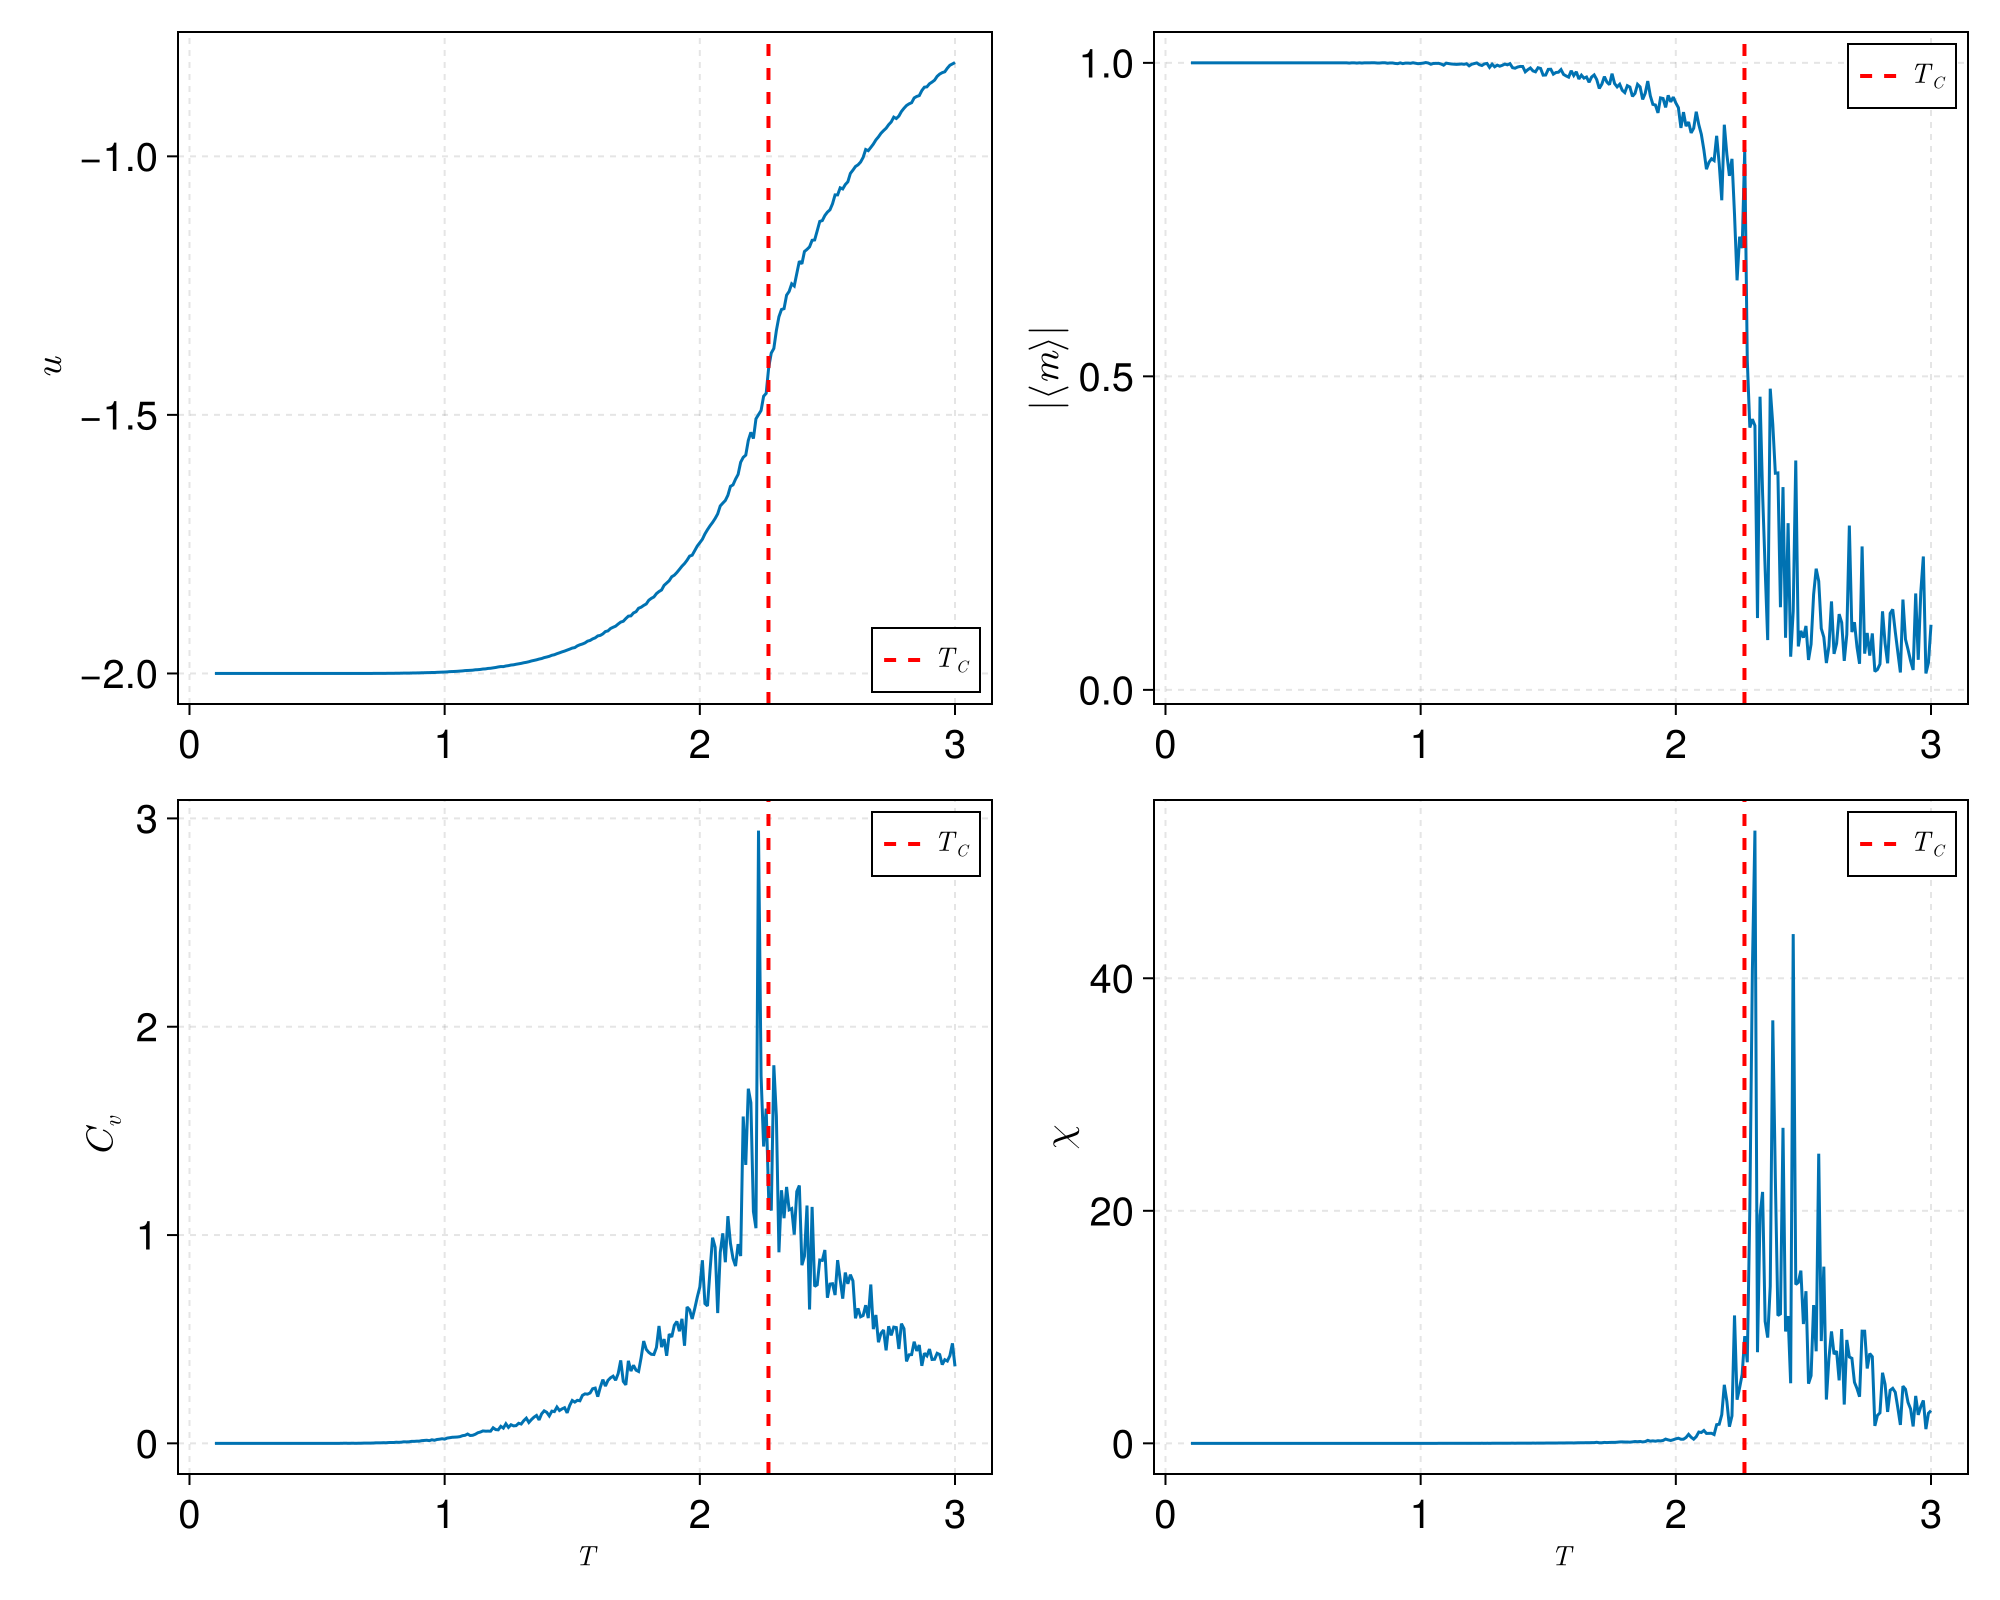

In [35]:
fig = Figure(size=(1000, 800))
ax1 = Axis(fig[1,1], ylabel=L"$u$")
ax2 = Axis(fig[1,2], ylabel=L"$|\langle m \rangle|$")
ax3 = Axis(fig[2,1], xlabel=L"$T$", ylabel=L"$C_v$")
ax4 = Axis(fig[2,2], xlabel=L"$T$", ylabel=L"$\chi$") 

lines!(ax1, T_range, E)
lines!(ax2, T_range, M)
lines!(ax3, T_range, Cv)
lines!(ax4, T_range, Chi)

vlines!(ax1, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")
vlines!(ax2, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")
vlines!(ax3, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")
vlines!(ax4, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")

axislegend(ax1, position = :rb)
axislegend(ax2, position = :rt)
axislegend(ax3, position = :rt)
axislegend(ax4, position = :rt)
fig 

In [36]:
T_range = collect(0.1:0.01:3.0) 
Ls = [8, 16, 32, 64]

E_l, M_l, Cv_l, Chi_l = [], [], [], []
for L in Ls
    @show L
    E, M, Cv, Chi = phase_diagram(L, T_range; thermal_sweeps = 2000, sampling_sweeps = 3000)
    push!(E_l, E)
    push!(M_l, M)
    push!(Cv_l, Cv)
    push!(Chi_l, Chi)
end 

L = 8
L = 16
L = 32
L = 64


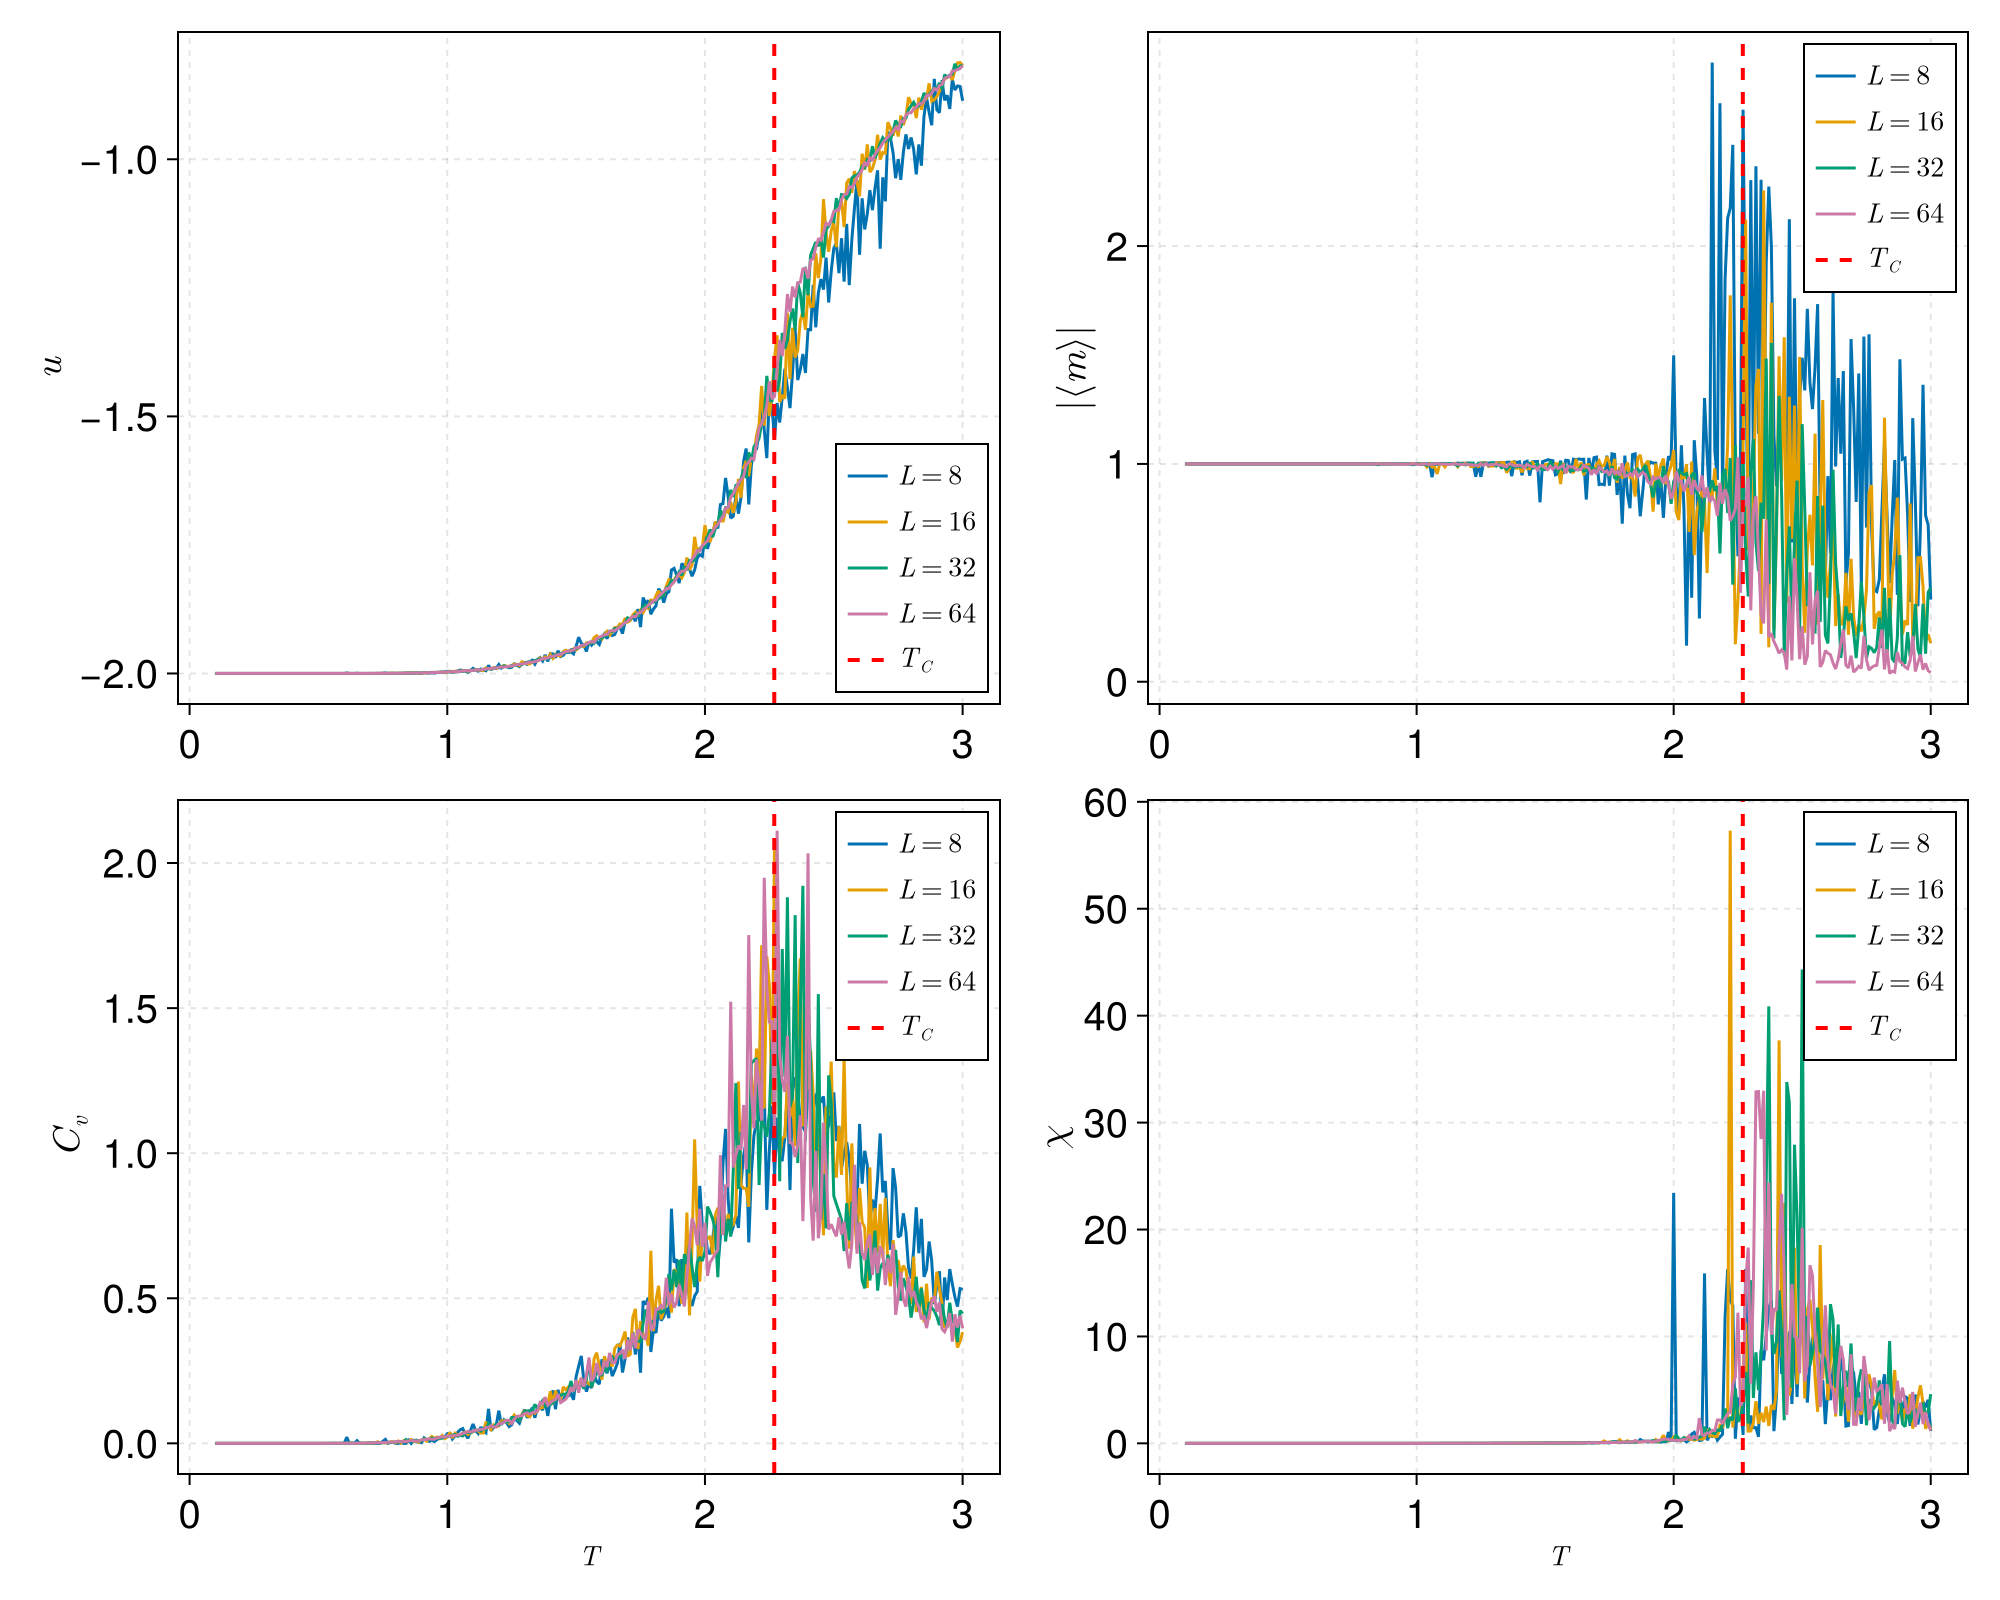

In [38]:
fig = Figure(size=(1000, 800))
ax1 = Axis(fig[1,1], ylabel=L"$u$")
ax2 = Axis(fig[1,2], ylabel=L"$|\langle m \rangle|$")
ax3 = Axis(fig[2,1], xlabel=L"$T$", ylabel=L"$C_v$")
ax4 = Axis(fig[2,2], xlabel=L"$T$", ylabel=L"$\chi$") 

Tc = 2.269

for i = 1:length(Ls) 
    L = Ls[i]
    lines!(ax1, T_range, E_l[i], label = L"L = %$L")
    lines!(ax2, T_range, M_l[i], label = L"L = %$L")
    lines!(ax3, T_range, Cv_l[i], label = L"L = %$L")
    lines!(ax4, T_range, Chi_l[i], label = L"L = %$L")
end

vlines!(ax1, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")
vlines!(ax2, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")
vlines!(ax3, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")
vlines!(ax4, Tc, color = :red, linestyle = :dash, linewidth = 2, label = L"$T_C$")

axislegend(ax1, position = :rb)
axislegend(ax2, position = :rt)
axislegend(ax3, position = :rt)
axislegend(ax4, position = :rt)
fig 